# Marginal Cost vs. Marginal Benefit: Economic Decision Modeling

This project explores how marginal cost (MC) and marginal benefit (MB) can be used to determine an economically efficient production level.

Using Python, we simulate the relationship between production quantity, costs, and benefits, identify the point where MB = MC, and verify the result through profit maximization. We also perform a sensitivity analysis to examine how changes in production costs affect the optimal decision.

The goal is to demonstrate how economic theory, mathematical modeling, and Python-based optimization can be combined to support quantitative decision-making.

## Import the libraries

In [1]:
# Numerical calculations
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize_scalar

# Display settings
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Define the economic problem

Suppose a firm produces a product.

As production increases:


*   consumers are willing to pay less for additional units → marginal benefit decreases
*   production becomes increasingly expensive → marginal cost increases


We'll model these relationships mathematically.

In [2]:
# Maximum production quantity
Q_MAX = 100

# Fixed cost of operating the business
FIXED_COST = 500

# Parameters controlling marginal benefit
MB_INTERCEPT = 120
MB_SLOPE = 0.8

# Parameters controlling marginal cost
MC_INTERCEPT = 10
MC_SLOPE = 0.6

We are creating a simplified economic environment.

The marginal benefit function will be:

$$ MB(Q) = 120 - 0.8Q $$

while marginal cost will be:

$$ MC(Q) = 10 + 0.6Q $$

The important feature is their opposite behavior:

$$ \frac{dMB}{dQ}<0 $$

and

$$ \frac{dMC}{dQ}>0 $$

So additional units become progressively less beneficial and more expensive.

## Create the production quantities

In [3]:
quantity = np.arange(0, Q_MAX + 1)

quantity[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## Define Marginal Benefit

In [4]:
def marginal_benefit(Q):
    """
    Calculate the marginal benefit of producing one additional unit.
    """
    return MB_INTERCEPT - MB_SLOPE * Q

Let's calculate MB for every possible production quantity.

In [5]:
MB = marginal_benefit(quantity)

MB[:10]

array([120. , 119.2, 118.4, 117.6, 116.8, 116. , 115.2, 114.4, 113.6,
       112.8])

Our equation is:

$$ MB(Q)=120-0.8Q $$

For example:

At \(Q=10\):

$$ MB(10)=120-(0.8)(10) $$ $$ MB(10)=112 $$

So the 10th additional unit provides approximately 112 units of benefit in this simplified model.

The important economic concept is diminishing marginal benefit.

## Define Marginal Cost

In [6]:
def marginal_cost(Q):
    """
    Calculate the marginal cost of producing one additional unit.
    """
    return MC_INTERCEPT + MC_SLOPE * Q

Calculate MC:

In [7]:
MC = marginal_cost(quantity)

MC[:10]

array([10. , 10.6, 11.2, 11.8, 12.4, 13. , 13.6, 14.2, 14.8, 15.4])

Our marginal cost function is:

$$ MC(Q)=10+0.6Q $$

For example:

$$ MC(10)=10+(0.6)(10) $$ $$ MC(10)=16 $$

The additional unit costs more as production increases.

This represents increasing marginal production costs.

## Create the economic dataset

In [8]:
df = pd.DataFrame({
    "Quantity": quantity,
    "Marginal Benefit": MB,
    "Marginal Cost": MC
})

df.head(10)

,Quantity,Marginal Benefit,Marginal Cost
0,0,120.00,10.00
1,1,119.20,10.60
2,2,118.40,11.20
3,3,117.60,11.80
4,4,116.80,12.40
5,5,116.00,13.00
6,6,115.20,13.60
7,7,114.40,14.20
8,8,113.60,14.80
9,9,112.80,15.40


## Find the optimal quantity

The central economic condition is:

$$ MB = MC $$

The firm should continue producing while:

$$ MB > MC $$

Once:

$$ MC > MB $$

the next unit costs more than the benefit it generates.

Let's calculate the theoretical intersection.

In [9]:
Q_star = (MB_INTERCEPT - MC_INTERCEPT) / (MB_SLOPE + MC_SLOPE)

Q_star

78.57142857142857

We solve:

$$ 120-0.8Q=10+0.6Q $$

Therefore:

$$ 110=1.4Q $$

and:

$$ Q^*=78.57 $$

So the continuous mathematical solution is approximately:

$$ \boxed{Q^*=78.57} $$

If production must be an integer, we can compare nearby quantities.

## Find the optimal integer production level

In [10]:
df["MB - MC"] = df["Marginal Benefit"] - df["Marginal Cost"]

optimal_row = df.loc[
    df["MB - MC"].abs().idxmin()
]

optimal_quantity = int(optimal_row["Quantity"])

optimal_quantity

79

Since we can only produce whole units, we find the quantity where:

$$ |MB-MC| $$

is smallest.

This gives the discrete approximation to the theoretical optimum.

## Visualize Marginal Benefit vs Marginal Cost

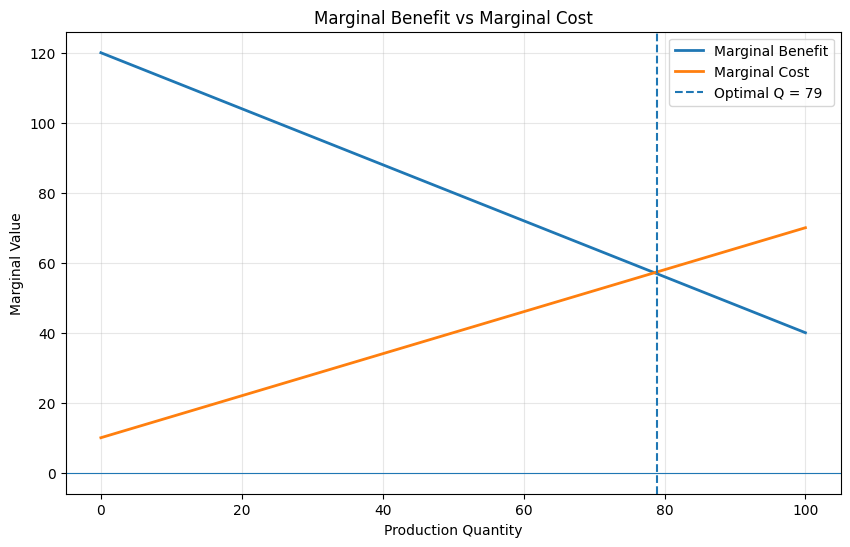

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["Quantity"],
    df["Marginal Benefit"],
    label="Marginal Benefit",
    linewidth=2
)

plt.plot(
    df["Quantity"],
    df["Marginal Cost"],
    label="Marginal Cost",
    linewidth=2
)

plt.axvline(
    optimal_quantity,
    linestyle="--",
    label=f"Optimal Q = {optimal_quantity}"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("Production Quantity")
plt.ylabel("Marginal Value")
plt.title("Marginal Benefit vs Marginal Cost")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

This is the key visualization of the project.

Before the intersection:

$$ MB > MC $$

Therefore, producing another unit creates more benefit than cost.

After the intersection:

$$ MC > MB $$

Therefore, producing additional units destroys economic value at the margin.

The intersection gives us the economically efficient production level.

## Calculate Total Benefit

Marginal benefit tells us about one additional unit.

To calculate total benefit, we accumulate the marginal benefits.

In [12]:
df["Total Benefit"] = df["Marginal Benefit"].clip(lower=0).cumsum()

df.head(10)

,Quantity,Marginal Benefit,Marginal Cost,MB - MC,Total Benefit
0,0,120.00,10.00,110.00,120.00
1,1,119.20,10.60,108.60,239.20
2,2,118.40,11.20,107.20,357.60
3,3,117.60,11.80,105.80,475.20
4,4,116.80,12.40,104.40,592.00
5,5,116.00,13.00,103.00,708.00
6,6,115.20,13.60,101.60,823.20
7,7,114.40,14.20,100.20,937.60
8,8,113.60,14.80,98.80,"1,051.20"
9,9,112.80,15.40,97.40,"1,164.00"


Conceptually:

$$ TB(Q)=\sum_{i=1}^{Q} MB_i $$

In continuous mathematics this corresponds to:

$$ TB(Q)=\int_0^Q MB(x)\,dx $$

So marginal analysis connects directly to calculus.

## Calculate Total Cost

We also need total cost.

Variable cost can be approximated by accumulating marginal costs.

In [13]:
df["Variable Cost"] = df["Marginal Cost"].cumsum()

df["Total Cost"] = FIXED_COST + df["Variable Cost"]

Total cost consists of:

$$ TC = FC + VC $$

where:

- **FC** = fixed cost
- **VC** = variable cost

Our fixed cost is:

$$ FC=500 $$

while variable cost increases as production increases.

## Calculate Profit

In [14]:
df["Profit"] = df["Total Benefit"] - df["Total Cost"]

df.head()

,Quantity,Marginal Benefit,Marginal Cost,MB - MC,Total Benefit,Variable Cost,Total Cost,Profit
0,0,120.00,10.00,110.00,120.00,10.00,510.00,-390.00
1,1,119.20,10.60,108.60,239.20,20.60,520.60,-281.40
2,2,118.40,11.20,107.20,357.60,31.80,531.80,-174.20
3,3,117.60,11.80,105.80,475.20,43.60,543.60,-68.40
4,4,116.80,12.40,104.40,592.00,56.00,556.00,36.00


We define profit as:

$$ \pi(Q)=TB(Q)-TC(Q) $$

The firm wants to find:

$$ \max_Q \pi(Q) $$

This gives us another way to identify the optimal quantity.

## Find the quantity that maximizes profit

In [15]:
profit_optimal_row = df.loc[df["Profit"].idxmax()]

profit_optimal_quantity = int(
    profit_optimal_row["Quantity"]
)

maximum_profit = profit_optimal_row["Profit"]

print("Optimal production quantity:", profit_optimal_quantity)
print("Maximum profit:", round(maximum_profit, 2))

Optimal production quantity: 78
Maximum profit: 3876.6


Notice something important:

We have now found the optimal quantity using two different approaches:

Marginal approach
$$ MB=MC $$
Profit approach
$$ \max \pi(Q) $$

These should produce approximately the same result.

This is an important connection between microeconomic theory and numerical optimization.

## Plot profit

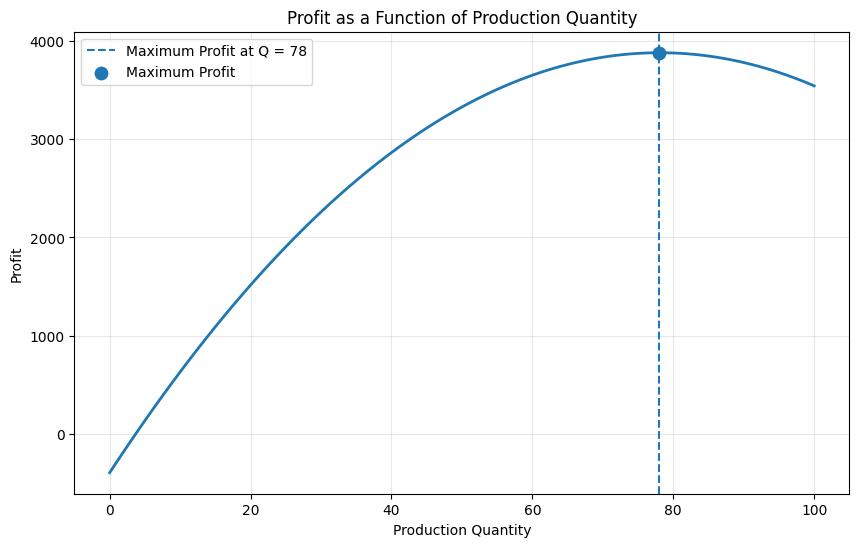

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["Quantity"],
    df["Profit"],
    linewidth=2
)

plt.axvline(
    profit_optimal_quantity,
    linestyle="--",
    label=f"Maximum Profit at Q = {profit_optimal_quantity}"
)

plt.scatter(
    profit_optimal_quantity,
    maximum_profit,
    s=80,
    label="Maximum Profit"
)

plt.xlabel("Production Quantity")
plt.ylabel("Profit")
plt.title("Profit as a Function of Production Quantity")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The graph should have a peak.

That peak represents:

$$ Q^*=\arg\max_Q \pi(Q) $$

In other words:

What production quantity gives the highest economic return?

## Compare the marginal and profit solutions

In [17]:
print("Marginal-analysis solution:", optimal_quantity)
print("Profit-maximizing solution:", profit_optimal_quantity)

difference = abs(
    optimal_quantity - profit_optimal_quantity
)

print("Difference:", difference)

Marginal-analysis solution: 79
Profit-maximizing solution: 78
Difference: 1


This is a useful validation step.

We're checking whether two different approaches produce consistent results.

In quantitative modeling, this is important because we don't want to rely on one calculation blindly.

## Visualize Total Benefit vs Total Cost

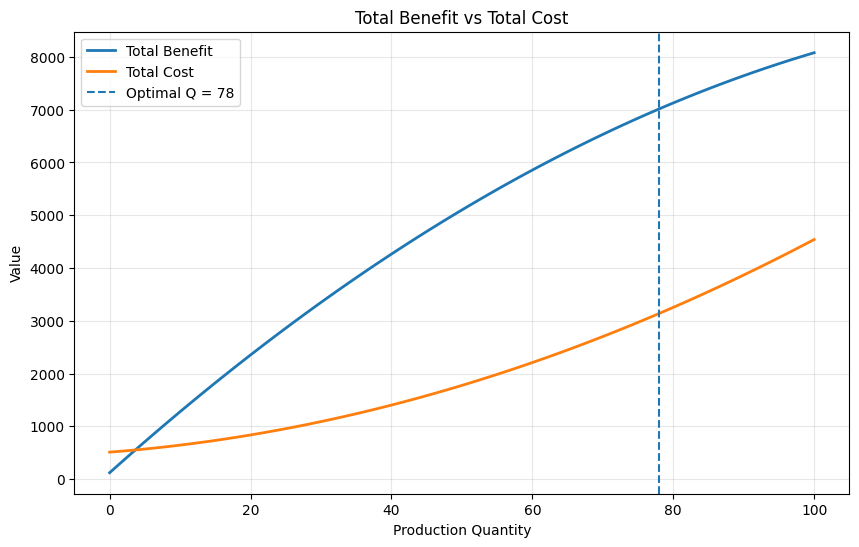

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["Quantity"],
    df["Total Benefit"],
    label="Total Benefit",
    linewidth=2
)

plt.plot(
    df["Quantity"],
    df["Total Cost"],
    label="Total Cost",
    linewidth=2
)

plt.axvline(
    profit_optimal_quantity,
    linestyle="--",
    label=f"Optimal Q = {profit_optimal_quantity}"
)

plt.xlabel("Production Quantity")
plt.ylabel("Value")
plt.title("Total Benefit vs Total Cost")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

This gives us the broader picture.

Marginal analysis asks:

What happens when we produce one more unit?

Total analysis asks:

What happens when we produce Q units in total?

Both perspectives are useful.

## Build a decision function

In [19]:
def evaluate_decision(Q):
    """
    Evaluate the economic outcome of producing Q units.
    """

    mb = marginal_benefit(Q)
    mc = marginal_cost(Q)

    return {
        "Quantity": Q,
        "Marginal Benefit": mb,
        "Marginal Cost": mc,
        "MB > MC": mb > mc,
        "Decision": (
            "Produce more"
            if mb > mc
            else "Stop increasing production"
        )
    }

We test it:

In [20]:
evaluate_decision(50)

{'Quantity': 50,
 'Marginal Benefit': 80.0,
 'Marginal Cost': 40.0,
 'MB > MC': True,
 'Decision': 'Produce more'}

In [21]:
evaluate_decision(90)

{'Quantity': 90,
 'Marginal Benefit': 48.0,
 'Marginal Cost': 64.0,
 'MB > MC': False,
 'Decision': 'Stop increasing production'}

## Sensitivity Analysis

We ask:

>"What haappens if the economic environment changes?"

We now want to examine different marginal-cost environments.

In [22]:
cost_slopes = [0.4, 0.6, 0.8, 1.0]

results = []

for slope in cost_slopes:

    Q_opt = (
        MB_INTERCEPT - MC_INTERCEPT
    ) / (
        MB_SLOPE + slope
    )

    results.append({
        "MC Slope": slope,
        "Optimal Quantity": Q_opt
    })

sensitivity_df = pd.DataFrame(results)

sensitivity_df

,MC Slope,Optimal Quantity
0,0.40,91.67
1,0.60,78.57
2,0.80,68.75
3,1.00,61.11


The slope of marginal cost represents how quickly production becomes expensive.

When marginal cost rises faster, the optimal quantity generally changes.

This is a simple example of sensitivity analysis.

## Visualize the sensitivity analysis

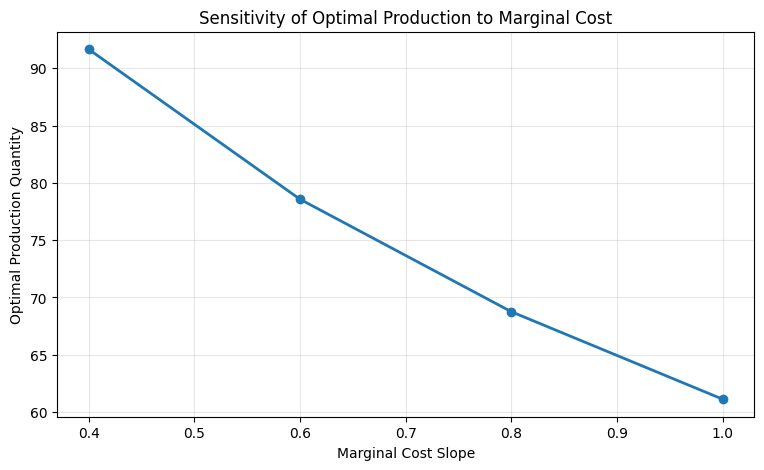

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    sensitivity_df["MC Slope"],
    sensitivity_df["Optimal Quantity"],
    marker="o",
    linewidth=2
)

plt.xlabel("Marginal Cost Slope")
plt.ylabel("Optimal Production Quantity")

plt.title(
    "Sensitivity of Optimal Production to Marginal Cost"
)

plt.grid(alpha=0.3)

plt.show()

This tells management how sensitive the production decision is to changes in cost structure.

For example:

- lower marginal-cost growth → more production can be justified
- higher marginal-cost growth → optimal production changes downward

The exact magnitude comes from the model parameters.

In [24]:
final = df.loc[
    df["Quantity"] == profit_optimal_quantity
].iloc[0]

print("=" * 50)
print("ECONOMIC DECISION SUMMARY")
print("=" * 50)

print(f"Optimal Quantity: {profit_optimal_quantity}")
print(f"Marginal Benefit: {final['Marginal Benefit']:.2f}")
print(f"Marginal Cost: {final['Marginal Cost']:.2f}")
print(f"Total Benefit: {final['Total Benefit']:.2f}")
print(f"Total Cost: {final['Total Cost']:.2f}")
print(f"Maximum Profit: {final['Profit']:.2f}")
print("=" * 50)

ECONOMIC DECISION SUMMARY
Optimal Quantity: 78
Marginal Benefit: 57.60
Marginal Cost: 56.80
Total Benefit: 7015.20
Total Cost: 3138.60
Maximum Profit: 3876.60


The entire project can be summarized by one principle:

$$ \boxed{MB > MC \Rightarrow \text{increase activity}} $$ $$ \boxed{MB < MC \Rightarrow \text{decrease/stop activity}} $$

and at the optimum:

$$ \boxed{MB=MC} $$

This is the core of marginal analysis.